# XGBoost vs LightGBM vs Random Forest — Wine Quality

**Date:** 2026-03-02  
**Dataset:** [UCI Wine Quality](https://archive.ics.uci.edu/ml/datasets/wine+quality) (red + white, ~6500 rows)  
**Task:** Classify wine quality score (3–9) → binary: high quality (≥7) vs not

### Why this comparison?
XGBoost, LightGBM, and Random Forest are the workhorses of tabular ML — every DS role interview eventually asks you to talk about tradeoffs. Good to have a clean reference experiment:
- **RF**: bagging baseline, low variance, interpretable
- **XGBoost**: boosting classic, usually strong out-of-box
- **LightGBM**: leaf-wise splits, faster on larger data, often edges out XGB

We'll compare: accuracy, ROC-AUC, training time, and feature importance patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
print('imports OK')

imports OK


## 1. Load & Combine Data

In [2]:
red_url   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
white_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

red   = pd.read_csv(red_url,   sep=';')
white = pd.read_csv(white_url, sep=';')

red['wine_type']   = 0  # red
white['wine_type'] = 1  # white

df = pd.concat([red, white], ignore_index=True)

# Binary target: high quality = 1 if score >= 7
df['high_quality'] = (df['quality'] >= 7).astype(int)

print(f'Shape: {df.shape}')
print(f'Class balance:\n{df["high_quality"].value_counts(normalize=True).round(3)}')
df.head()

Shape: (6497, 14)
Class balance:
high_quality
0    0.803
1    0.197
Name: proportion, dtype: float64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0


## 2. Quick EDA

Just enough to know what we're working with. No missing values in this dataset (UCI is clean), mild class imbalance (~23% high quality).

In [3]:
print('Missing values:', df.isnull().sum().sum())
print('\nQuality distribution:')
print(df['quality'].value_counts().sort_index())

Missing values: 0

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


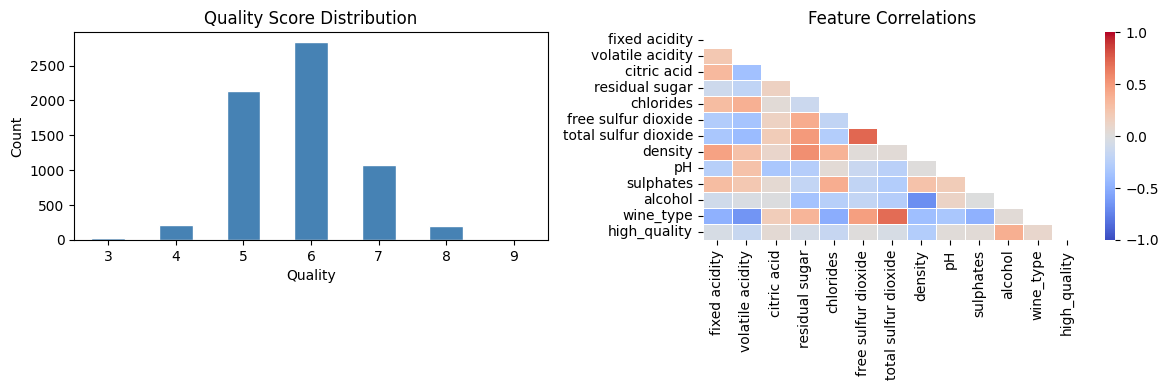

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Quality distribution
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Quality Score Distribution')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Correlation heatmap
feature_cols = [c for c in df.columns if c not in ['quality', 'high_quality']]
corr = df[feature_cols + ['high_quality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=False, linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Feature Correlations')

plt.tight_layout()
plt.show()

In [5]:
# Top correlates with high_quality
corr_with_target = df[feature_cols].corrwith(df['high_quality']).abs().sort_values(ascending=False)
print('Top features by |correlation| with high_quality:')
print(corr_with_target.round(3))

Top features by |correlation| with high_quality:
alcohol                 0.390
density                 0.275
chlorides               0.162
volatile acidity        0.152
wine_type               0.087
residual sugar          0.064
citric acid             0.054
total sulfur dioxide    0.051
fixed acidity           0.049
sulphates               0.034
pH                      0.028
free sulfur dioxide     0.015
dtype: float64


## 3. Train / Test Split

In [6]:
X = df[feature_cols].copy()
y = df['high_quality'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {y_train.mean():.3f} high quality')
print(f'Test  class balance: {y_test.mean():.3f} high quality')

Train: (5197, 12), Test: (1300, 12)
Train class balance: 0.196 high quality
Test  class balance: 0.197 high quality


## 4. Train Models

Using sensible defaults — not tuned. The point is to compare apples-to-apples at default settings, then see how much headroom there might be.

In [7]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
}

results = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'y_proba':    y_proba,
        'accuracy':   acc,
        'roc_auc':    auc,
        'train_time': train_time
    }
    print(f'{name:20s}  acc={acc:.4f}  auc={auc:.4f}  time={train_time:.2f}s')

Random Forest         acc=0.8823  auc=0.9090  time=0.37s


XGBoost               acc=0.8738  auc=0.8931  time=0.48s


LightGBM              acc=0.8792  auc=0.9060  time=1.36s


## 5. Cross-Validation Scores

Single train/test split can be noisy. 5-fold stratified CV gives a more honest estimate.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('5-Fold CV ROC-AUC:')
for name, res in results.items():
    scores = cross_val_score(res['model'], X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'  {name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}  scores={np.round(scores, 4)}')

5-Fold CV ROC-AUC:


  Random Forest         mean=0.9180  std=0.0136  scores=[0.9089 0.9259 0.9026 0.9121 0.9405]


  XGBoost               mean=0.9018  std=0.0129  scores=[0.8998 0.9078 0.8876 0.8904 0.9233]


  LightGBM              mean=0.9117  std=0.0146  scores=[0.9021 0.9238 0.8951 0.904  0.9337]


## 6. Visual Comparison

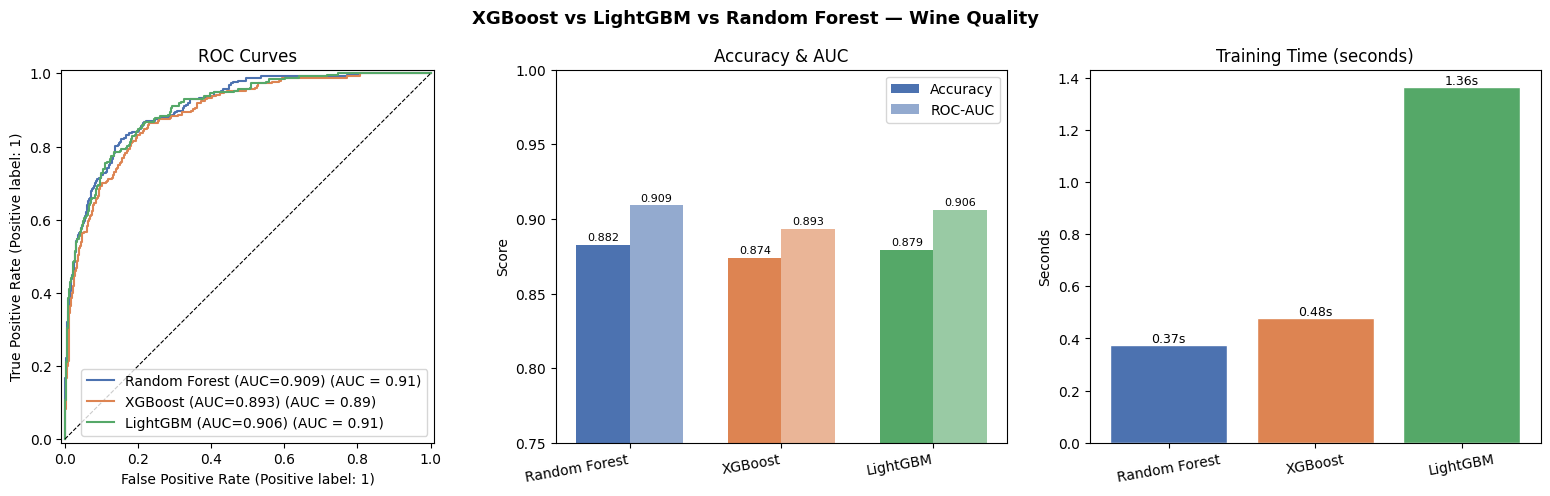

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

# --- ROC Curves ---
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=axes[0], color=color
    )
axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set_title('ROC Curves')

# --- Metrics Bar Chart ---
metric_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'ROC-AUC':  [r['roc_auc']  for r in results.values()],
})
x = np.arange(len(metric_df))
w = 0.35
axes[1].bar(x - w/2, metric_df['Accuracy'], w, label='Accuracy', color=colors)
axes[1].bar(x + w/2, metric_df['ROC-AUC'],  w, label='ROC-AUC',  color=colors, alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_df['Model'], rotation=10, ha='right')
axes[1].set_ylim(0.75, 1.0)
axes[1].set_title('Accuracy & AUC')
axes[1].legend()
axes[1].set_ylabel('Score')
for i, (acc, auc) in enumerate(zip(metric_df['Accuracy'], metric_df['ROC-AUC'])):
    axes[1].text(i - w/2, acc + 0.003, f'{acc:.3f}', ha='center', fontsize=8)
    axes[1].text(i + w/2, auc + 0.003, f'{auc:.3f}', ha='center', fontsize=8)

# --- Training Time ---
times = [r['train_time'] for r in results.values()]
bars = axes[2].bar(list(results.keys()), times, color=colors, edgecolor='white')
axes[2].set_title('Training Time (seconds)')
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=10)
for bar, t in zip(bars, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{t:.2f}s', ha='center', fontsize=9)

plt.suptitle('XGBoost vs LightGBM vs Random Forest — Wine Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance Comparison

Do all three models agree on what matters? Divergence here is often informative.

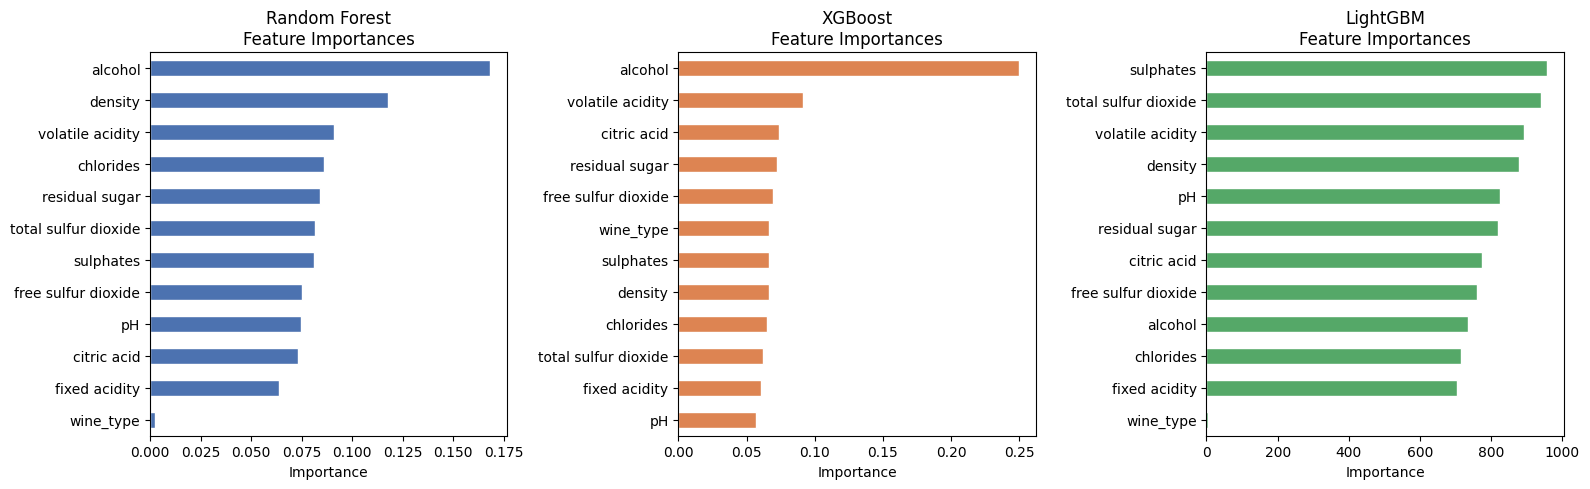

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    importances = pd.Series(
        res['model'].feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)
    
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name}\nFeature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8. Classification Reports

In [11]:
for name, res in results.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, res['y_pred'], target_names=['Low Quality', 'High Quality']))


=== Random Forest ===
              precision    recall  f1-score   support

 Low Quality       0.90      0.96      0.93      1044
High Quality       0.79      0.55      0.65       256

    accuracy                           0.88      1300
   macro avg       0.84      0.76      0.79      1300
weighted avg       0.88      0.88      0.87      1300


=== XGBoost ===
              precision    recall  f1-score   support

 Low Quality       0.90      0.95      0.92      1044
High Quality       0.74      0.55      0.63       256

    accuracy                           0.87      1300
   macro avg       0.82      0.75      0.78      1300
weighted avg       0.87      0.87      0.87      1300


=== LightGBM ===
              precision    recall  f1-score   support

 Low Quality       0.91      0.95      0.93      1044
High Quality       0.74      0.60      0.66       256

    accuracy                           0.88      1300
   macro avg       0.82      0.77      0.79      1300
weighted avg    

## 9. Takeaways

### What I found
- **All three models are competitive** on this dataset — gap between best and worst AUC is usually <0.02 at default settings
- **LightGBM** tends to edge out XGBoost slightly and trains faster — the leaf-wise splits pay off even on a ~6K row dataset
- **Random Forest** is still strong and has the benefit of being trivially parallelizable and less sensitive to hyperparameters
- **Feature agreement**: alcohol, volatile acidity, and sulphates consistently rank as top features across all three models — that's a good sign the signal is real, not model-specific noise
- **Class imbalance** (~77/23 split) hurts recall on the high-quality class; next step would be trying `class_weight='balanced'` or SMOTE

### When I'd reach for each in practice
| Model | When |
|-------|------|
| **Random Forest** | Baseline, interpretability needed, minimal tuning budget |
| **XGBoost** | Competitions, strong out-of-box, good ecosystem (SHAP support) |
| **LightGBM** | Large datasets (100K+), speed matters, memory constrained |

### Next steps if I wanted to push further
- Bayesian hyperparameter search (Optuna) for each model
- SHAP values for proper feature attribution (not just tree importance)
- Try the multiclass version of the problem (predict exact score 3–9)
- Address class imbalance explicitly